# **02. SQL Analysis of clean dataset**

This notebook presents a structured analysis of the retail sales dataset using SQL queries. The analysis is organized into four sections:
1. **Revenue analysis**: examines revenue trends over time to identify seasonal patterns, and ranks products and countries by their contribution to total revenue.   

2. **Volume analysis**: mirrors the revenue analysis from a volume perspective. Since product prices vary significantly, volume and revenue rankings may diverge; this section helps clarify those differences.

3. **Returns analysis**: investigates return rates over time, identifying which countries and products account for the highest proportion of returns.

4. **Customer analysis**: investigates return rates over time, identifying which countries and products account for the highest proportion of returns.    

In [1]:
import sys
sys.path.append('../src')
from models import SalesRecord, ReturnRecord, Invoice

import pandas as pd
import sqlite3
from sqlalchemy import create_engine

In [2]:
import matplotlib.pyplot as plt

In [3]:
df_sales = pd.read_csv("../data/sales_clean.csv",dtype={"Customer ID": "str"})
df_returns = pd.read_csv("../data/returns_clean.csv",dtype={"Customer ID": "str"})

In [4]:
# create SQLite database
engine = create_engine("sqlite:///../data/retail.db")

# load dataframes
df_sales.to_sql('sales', engine, if_exists='replace', index=False)
df_returns.to_sql('returns', engine, if_exists='replace', index=False)

17915

## 2.1 Revenue analysis

For the following revenue analysis, net revenue is considered after subtracting the revenue loss due to returns to the revenue gain from sales. While a separate section focuses on the returns analysis, it has been deemed meaningful to analyze net revenue since it is arguably the most important indicator for a company.    
The temporal analysis shows the net revenue agains the sales revenue, to better understand the gap between the two, while successive revenue trends only focus on the net revenue.

### 2.1.1 Temporal revenue trends

#### **Monthly revenue trend**
To get a general overview of revenue trends, let us first visualize them across all months.

In [5]:
q_net_revenue = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM (SELECT InvoiceDate, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Price, Quantity FROM returns
        )
    GROUP BY year_month
    ORDER BY year_month
    """

q_sales = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """

df_net_rev = pd.read_sql(q_net_revenue,engine) # Net revenue
df_sal_rev = pd.read_sql(q_sales,engine)   # Sales revenue

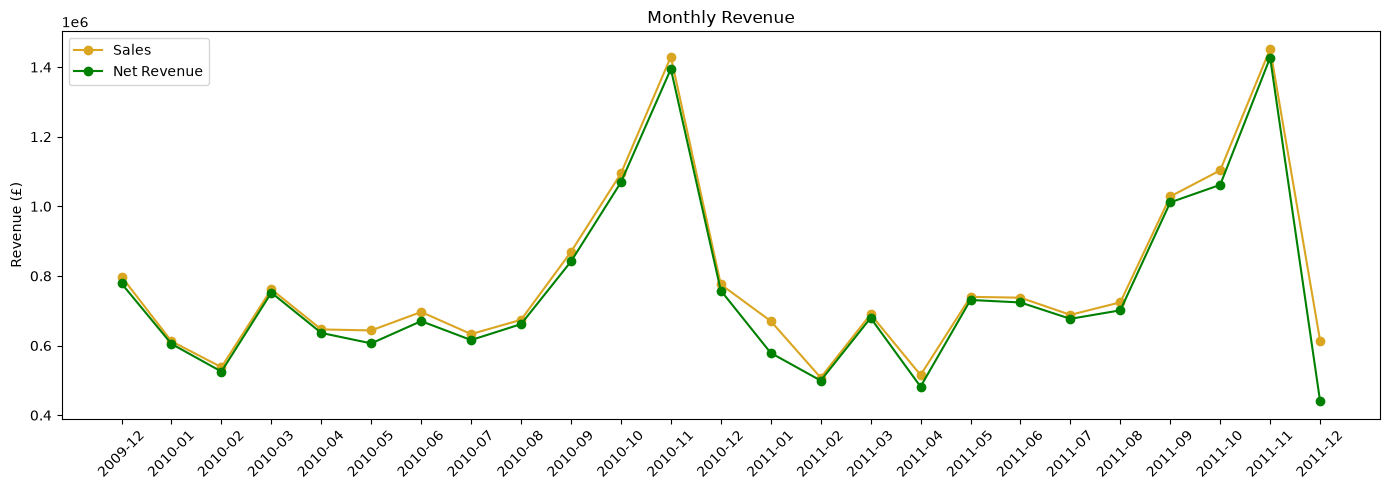

In [6]:
# Plot results
plt.figure(figsize=(14,5))
#plt.plot(df_ret["year_month"], df_ret["revenue"],c="red", label="Returns")
plt.plot(df_sal_rev["year_month"], df_sal_rev["revenue"],c="goldenrod", label="Sales", marker='o')
plt.plot(df_net_rev["year_month"], df_net_rev["revenue"],c="green", label="Net Revenue", marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.ylabel("Revenue (£)")
plt.legend()
plt.tight_layout()
plt.show()

#### **Quarterly revenue trend**
For this step of the analysis, the 2009 year has been left out, since the dataset only contains data for the month of December 2009.    

In [7]:
q_net_rev_quart = """
    SELECT SUM(Price*Quantity) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM (SELECT InvoiceDate, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Price, Quantity FROM returns
        )
    WHERE year!='2009'
    GROUP BY year, quarter
    """

q_sal_rev_quart = """
    SELECT SUM(Price*Quantity) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM sales
    WHERE year!='2009'
    GROUP BY year, quarter
    """

df_net_rev_quart = pd.read_sql(q_net_rev_quart,engine)
df_sal_rev_quart = pd.read_sql(q_sal_rev_quart,engine)

df_net_rev_quart["year_quarter"] = df_net_rev_quart["year"] + "-" + df_net_rev_quart["quarter"]
df_sal_rev_quart["year_quarter"] = df_sal_rev_quart["year"] + "-" + df_sal_rev_quart["quarter"]

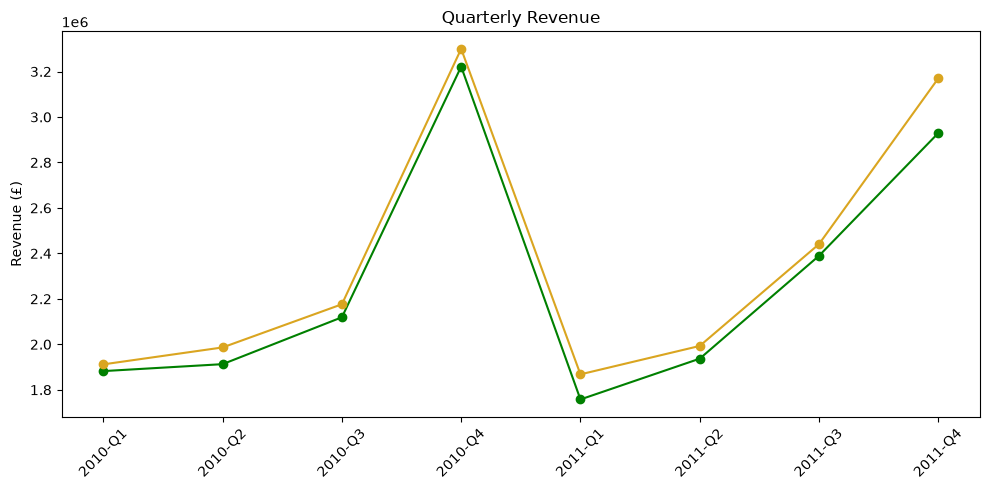

In [8]:
plt.figure(figsize=(10,5))
plt.plot(df_net_rev_quart["year_quarter"], df_net_rev_quart["revenue"],c="green", marker='o', label="Net Revenue")
plt.plot(df_sal_rev_quart["year_quarter"], df_sal_rev_quart["revenue"],c="goldenrod", marker='o', label="Sales Revenue")
plt.xticks(rotation=45)
plt.title("Quarterly Revenue")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

The trend seems to be consistent for the 4 quarters of years 2010-2011: The total revenue slowly increases from Q1 to Q3, which is followed by a steep increase in revenue in Q4.    
The total revenue then drops again by Q1.    
This behaviour may be consistent with the generally high volume of sales that most stores experience when festivities approach, which mostly occur in Q4.

In [118]:
rev_2010 = df_net_rev_quart[df_net_rev_quart["year"]=='2010']["revenue"].sum()
rev_2011 = df_net_rev_quart[df_net_rev_quart["year"]=='2011']["revenue"].sum()

q4_2010 = df_net_rev_quart[df_net_rev_quart["year_quarter"]=='2010-Q4']["revenue"].item()
q4_2011 = df_net_rev_quart[df_net_rev_quart["year_quarter"]=='2011-Q4']["revenue"].item()

print(f"In 2010, Q4 revenues account for {(q4_2010/rev_2010)*100:.2f}% of yearly revenue.")
print(f"In 2011, Q4 revenues account for {(q4_2011/rev_2011)*100:.2f}% of yearly revenue.")

In 2010, Q4 revenues account for 35.26% of yearly revenue.
In 2011, Q4 revenues account for 32.50% of yearly revenue.


**For both years, Quarter 4 (October-December) accounts for more than $30$% of yearly sales.**

### 2.1.2 Revenue per Country

In [85]:
q_country_net_rev = """
    SELECT SUM(Price*Quantity) AS revenue, Country
    FROM (SELECT Country, Price, Quantity FROM sales
        UNION ALL
        SELECT Country, Price, Quantity FROM returns
        )
    GROUP BY Country
    ORDER BY revenue DESC
    """

df_country_net_rev = pd.read_sql(q_country_net_rev, engine)
df_country_net_rev["revenue_pct"]=df_country_net_rev["revenue"]/(df_country_net_rev["revenue"].sum())*100

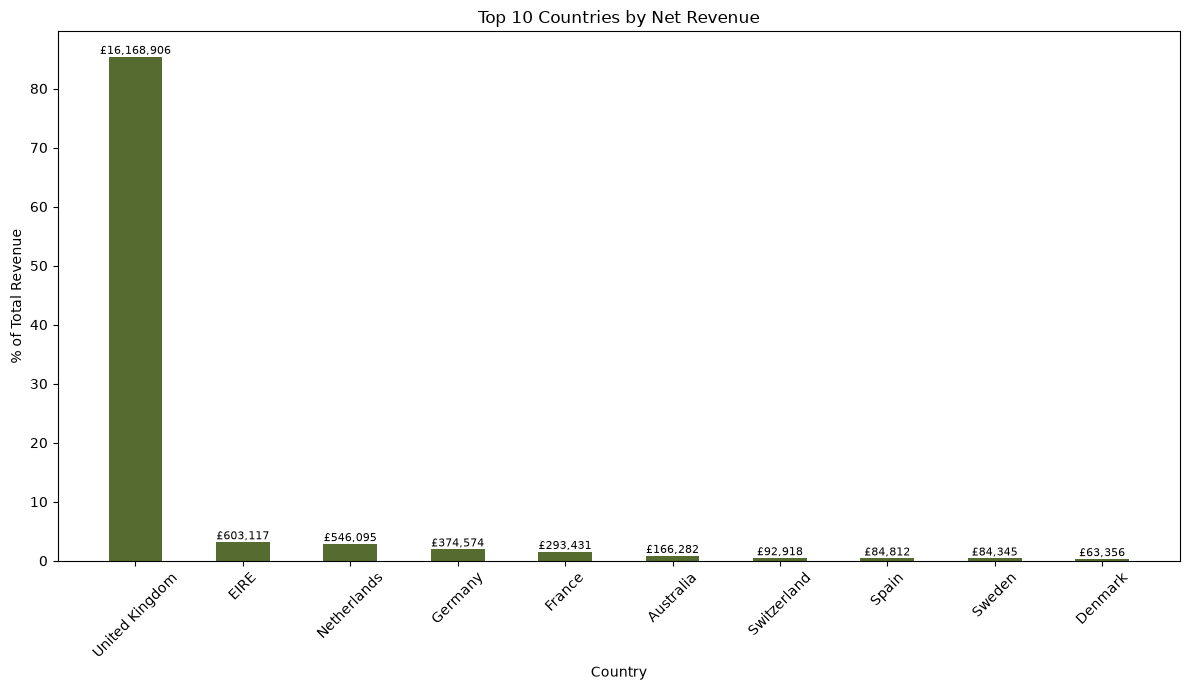

In [93]:
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(df_country_net_rev["Country"][:10], 
              df_country_net_rev["revenue_pct"][:10], 
              width=0.5, color="darkolivegreen")

for bar, val in zip(bars, df_country_net_rev["revenue"][:10]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'£{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Country")
ax.set_ylabel("% of Total Revenue")
ax.set_title("Top 10 Countries by Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [87]:
uk_rev = df_country_net_rev[df_country_net_rev["Country"]=="United Kingdom"]["revenue_pct"].item()

print(f"United Kingdom is responsible for {uk_rev:.2f}% of the total revenue.")

United Kingdom is responsible for 85.43% of the total revenue.


### 2.1.3 Revenue per Product

In [88]:
q_prod_net_rev = """
    SELECT UPPER(StockCode) as stock_code, Description, SUM(Price*Quantity) as revenue
    FROM (SELECT StockCode, Description, Price, Quantity FROM sales
        UNION ALL
        SELECT StockCode, Description, Price, Quantity FROM returns
        )
    GROUP BY stock_code
    ORDER BY revenue DESC
    """

df_prod_net_rev = pd.read_sql(q_prod_net_rev, engine)
df_prod_net_rev["revenue_pct"] = df_prod_net_rev["revenue"]/df_prod_net_rev["revenue"].sum() *100

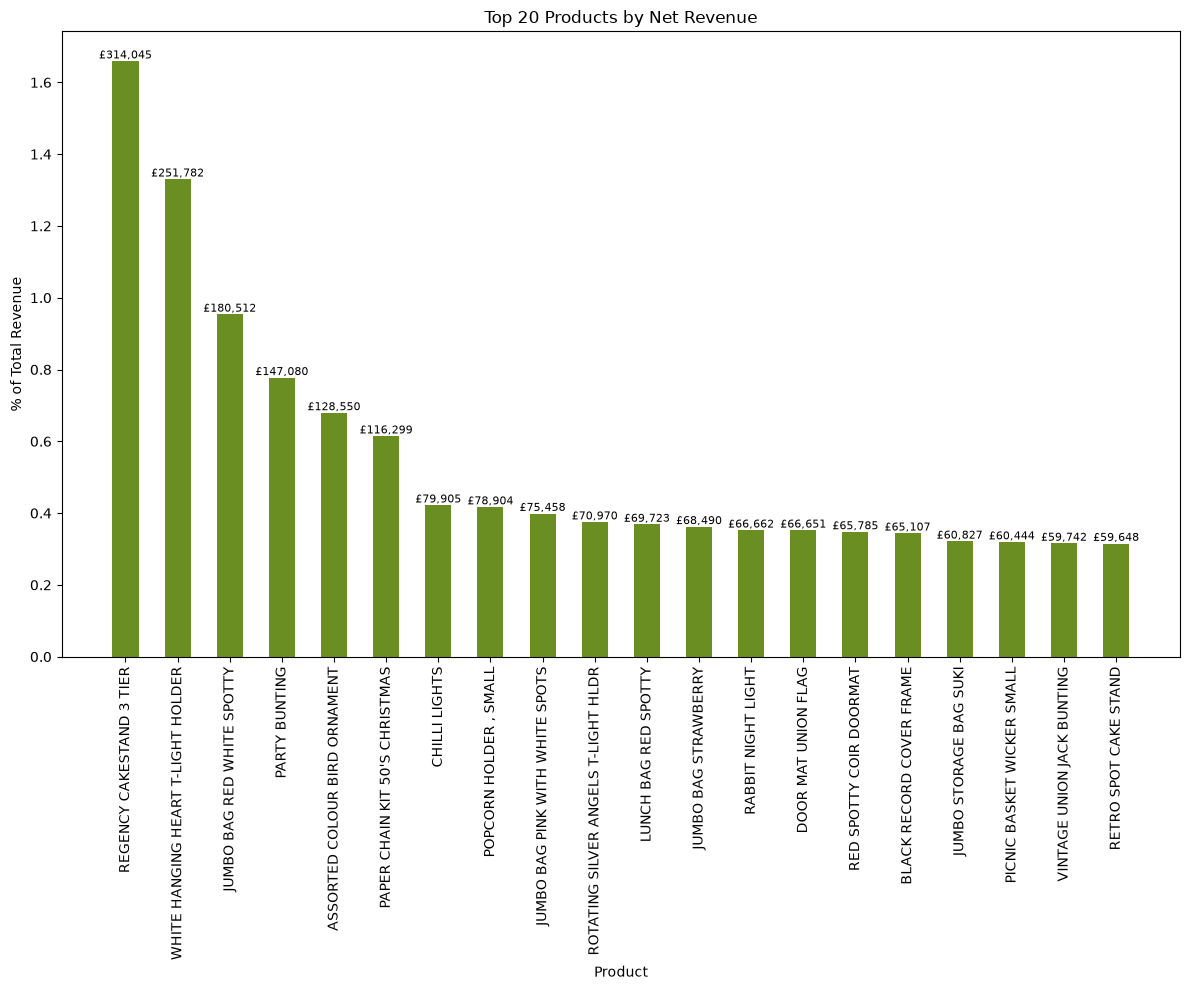

In [91]:
fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.bar(df_prod_net_rev["Description"][:20], 
              df_prod_net_rev["revenue_pct"][:20], 
              width=0.5, color="olivedrab")

for bar, val in zip(bars, df_prod_net_rev["revenue"][:20]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'£{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Product")
ax.set_ylabel("% of Total Revenue")
ax.set_title("Top 20 Products by Net Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### **Pareto analysis**

<div style="background:#00000; padding:12px; border-left:5px solid #3b82f6;">
<b>Note on Products with negative net revenue</b><br>
For the Pareto analysis we want to verify that 20% of products contribute to 80% of total revenue. To do so, in this case, we must work with only sales: products with negative net revenue (due to returns of items purchased in previous years) alter the computation of cumulative revenue and are therefore left out from thi section.
</div>

In [71]:
q_prod_sal = """
    SELECT UPPER(StockCode) as stock_code, Description, SUM(Price*Quantity) as revenue
    FROM sales
    GROUP BY stock_code
    ORDER BY revenue DESC
    """

df_prod_sal = pd.read_sql(q_prod_sal, engine)

In [72]:
df_prod_sal["revenue_pct"] = df_prod_sal["revenue"] / df_prod_sal["revenue"].sum() * 100

df_prod_sal["cumulative_revenue"]=df_prod_sal["revenue"].cumsum()
df_prod_sal["cumulative_pct"]=df_prod_sal["cumulative_revenue"]/df_prod_sal["revenue"].sum()*100

df_prod_sal["product_pct"]=range(1,len(df_prod_sal)+1)
df_prod_sal["product_pct"]=df_prod_sal["product_pct"]/len(df_prod_sal)*100

In [73]:
pareto = df_prod_sal[df_prod_sal["cumulative_pct"]>=80].iloc[0]
print(f"80% of revenue is generated by the top {pareto['product_pct']:.1f}% of products.")

80% of revenue is generated by the top 21.8% of products.


## 2.2 Volume analysis


The second step of the analysis focuses on the volume of sales, where we basically repeat the same analysis as we did for revenue, this time focusing on the number of objects sold.    
Since the returns analysis will be performed separately, this section only focuses on the total number of sales without taking returns into consideration.

### 2.2.1 Temporal volume trends

#### **Monthly volume of sales**

In [26]:
q_sal_vol = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Quantity) AS volume
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """
df_sal_vol = pd.read_sql(q_sal_vol,engine)   # Sales revenue

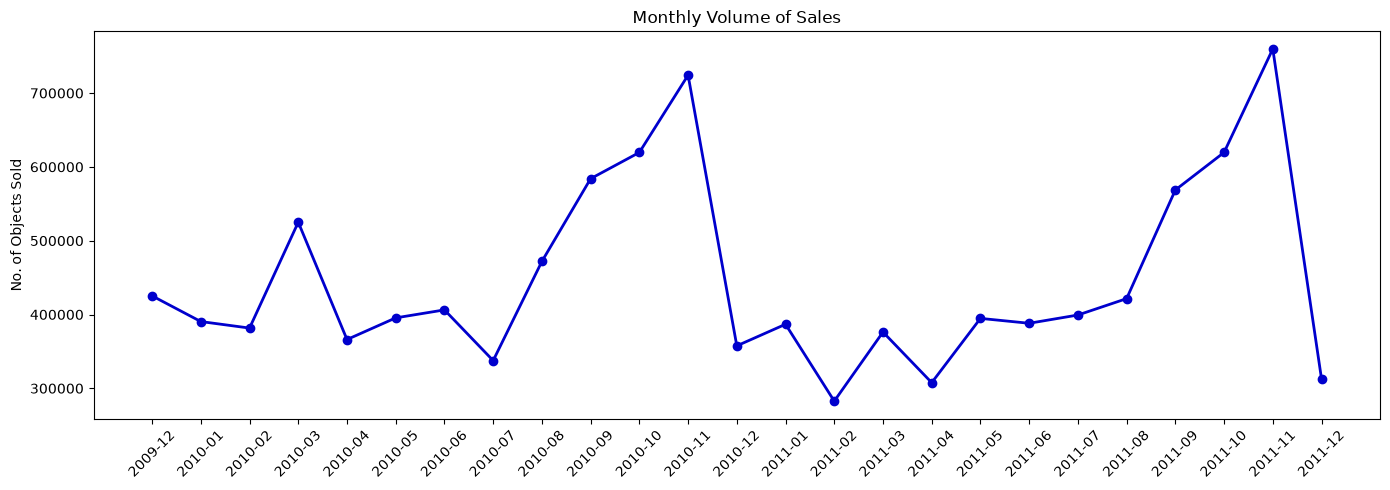

In [27]:

# Plot results
plt.figure(figsize=(14,5))
plt.plot(df_sal_vol["year_month"], df_sal_vol["volume"],c="mediumblue",linewidth=2, label="Sales", marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Volume of Sales")
plt.ylabel("No. of Objects Sold")
plt.tight_layout()
plt.show()

#### **Quarterly volume of sales**

In [28]:
q_vol_quart = """
    SELECT SUM(Quantity) AS volume, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM sales
    WHERE year!='2009'
    GROUP BY year, quarter
    """

df_sal_quart = pd.read_sql(q_vol_quart,engine)
df_sal_quart["year_quarter"] = df_sal_quart["year"] + "-" + df_sal_quart["quarter"]

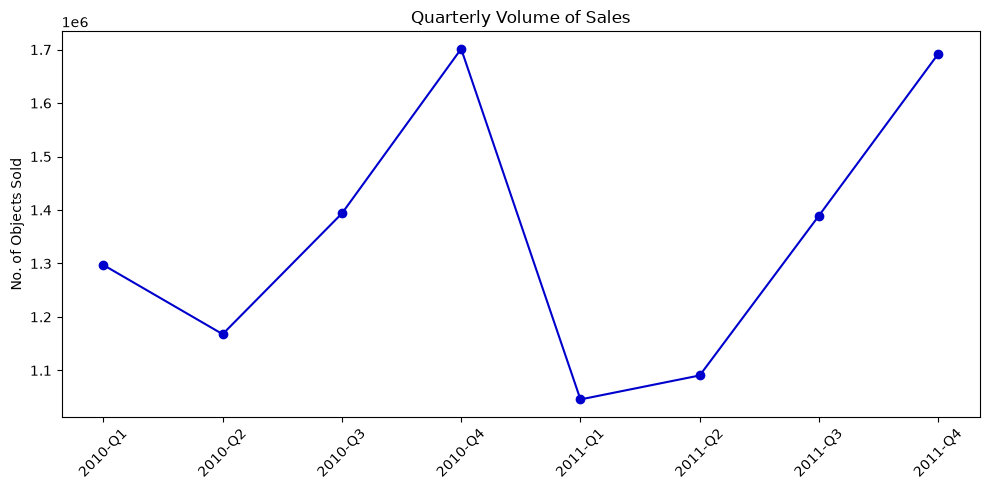

In [29]:
plt.figure(figsize=(10,5))
plt.plot(df_sal_quart["year_quarter"], df_sal_quart["volume"],c="mediumblue", marker='o')
plt.xticks(rotation=45)
plt.title("Quarterly Volume of Sales")
plt.ylabel("No. of Objects Sold")
plt.tight_layout()
plt.show()

Predictably, the quarterly trend for the volume of sales closely follows the one observed for the sales revenue.

In [31]:
sal_2010 = df_sal_quart[df_sal_quart["year"]=='2010']["volume"].sum()
sal_2011 = df_sal_quart[df_sal_quart["year"]=='2011']["volume"].sum()

q4_2010_vol = df_sal_quart[df_sal_quart["year_quarter"]=='2010-Q4']["volume"].item()
q4_2011_vol = df_sal_quart[df_sal_quart["year_quarter"]=='2011-Q4']["volume"].item()

print(f"In 2010, Q4 sales account for {(q4_2010_vol/sal_2010)*100:.2f}% of yearly sales.")
print(f"In 2011, Q4 sales account for {(q4_2011_vol/sal_2011)*100:.2f}% of yearly sales.")

In 2010, Q4 sales account for 30.60% of yearly sales.
In 2011, Q4 sales account for 32.43% of yearly sales.


The above results, consistently with what was observed with the revenue analysis, confirms that **more than $30$% of yearly sales are accounted for by Quarter 4**.

### 2.2.2 Volume of sales per Country

In [96]:
q_country_vol = """
    SELECT SUM(Quantity) as volume, Country
    FROM sales
    GROUP BY Country
    ORDER BY volume DESC
    """

df_country_vol = pd.read_sql(q_country_vol, engine)
df_country_vol["volume_pct"] = df_country_vol["volume"]/df_country_vol["volume"].sum() *100

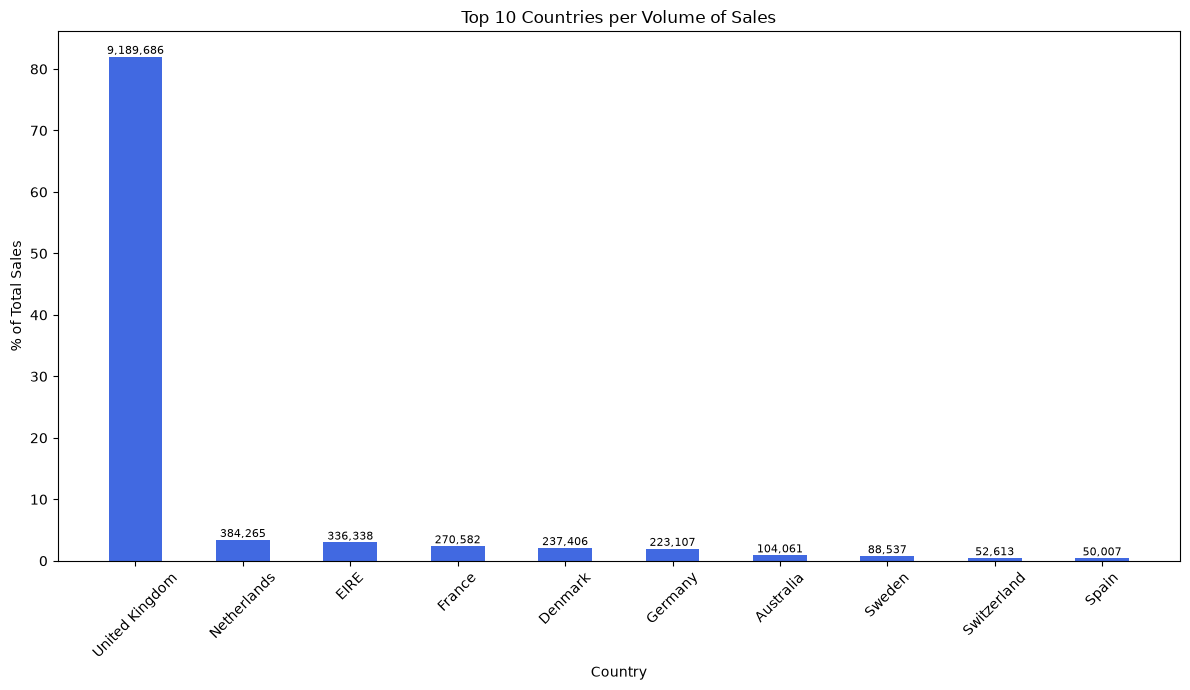

In [98]:
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(df_country_vol["Country"][:10], 
              df_country_vol["volume_pct"][:10], 
              width=0.5, color="royalblue")

for bar, val in zip(bars, df_country_vol["volume"][:10]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Country")
ax.set_ylabel("% of Total Sales")
ax.set_title("Top 10 Countries per Volume of Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [99]:
uk_vol = df_country_vol[df_country_vol["Country"]=="United Kingdom"]["volume_pct"].item()

print(f"United Kingdom is responsible for {uk_vol:.2f}% of the total volume of sales.")

United Kingdom is responsible for 82.03% of the total volume of sales.


### 2.2.3 Volume of sales per Product

In [100]:
q_prod_vol = """
    SELECT UPPER(StockCode) as stock_code, Description, SUM(Quantity) as volume
    FROM sales
    GROUP BY stock_code
    ORDER BY volume DESC
    """

df_prod_vol = pd.read_sql(q_prod_vol, engine)
df_prod_vol["volume_pct"] = df_prod_vol["volume"]/df_prod_vol["volume"].sum() *100

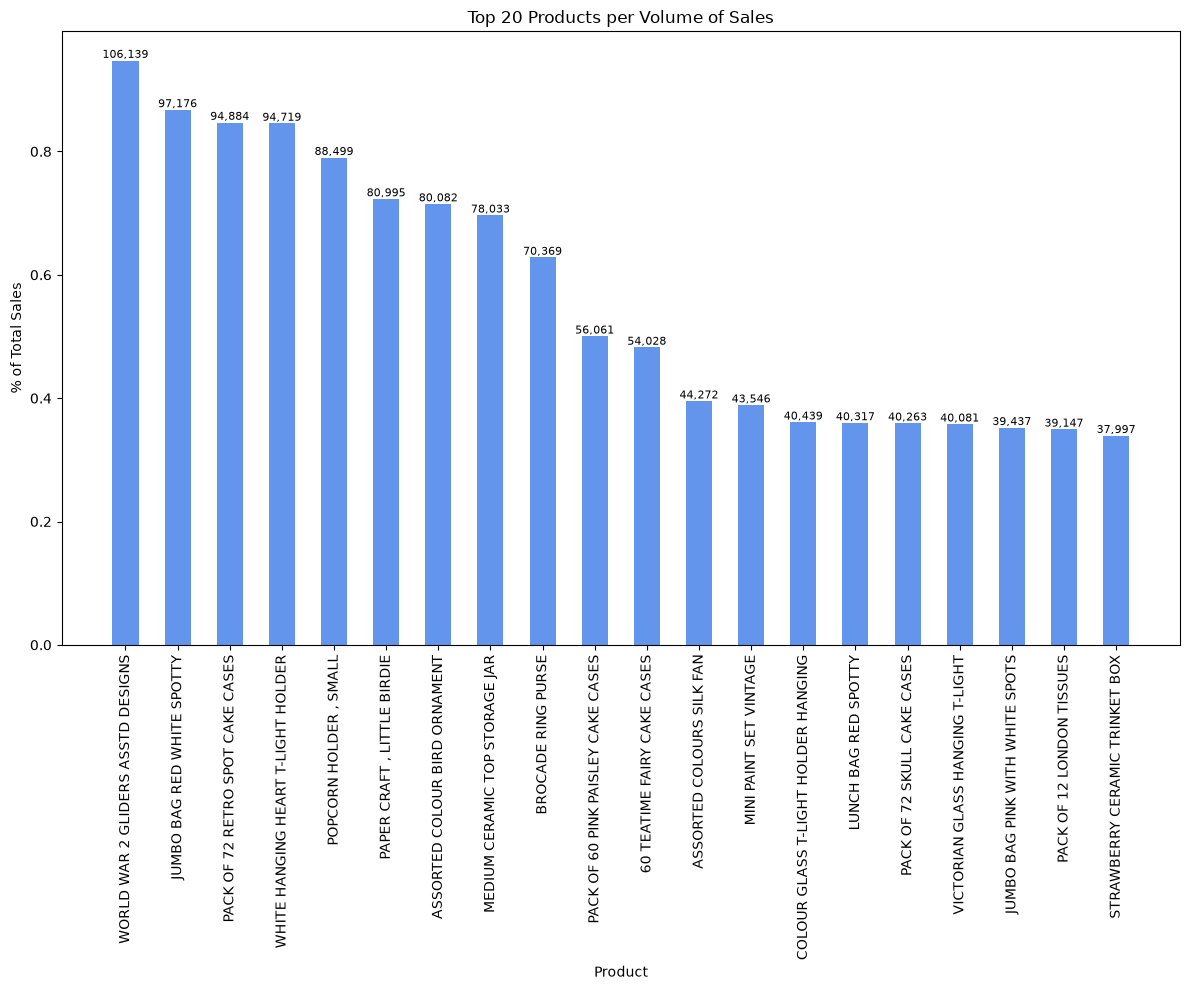

In [101]:
fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.bar(df_prod_vol["Description"][:20], 
              df_prod_vol["volume_pct"][:20], 
              width=0.5, color="cornflowerblue")

for bar, val in zip(bars, df_prod_vol["volume"][:20]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Product")
ax.set_ylabel("% of Total Sales")
ax.set_title("Top 20 Products per Volume of Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 2.3 Returns analysis

### 2.3.1 Temporal return rate trends

For the temporal analysis of returns we focus on the returns rate rather than the absolute number of returns, i.e. the percentage or returns over the total sales.    

While they might be similar in trend, the return rate is more informative than the absolute number of returns, as it relates the returns with the total number of sales. A higher absolute number of returns could indicate a problem with a product or with the company in a certain period, or it could just be naturally caused by the higher amount of sales: identifying which is the case becomes much simpler if we monitor the return rate.       

To gather insight on the actual trend in returns, and what they are caused by, it's important to always relate them with the total number of sales.

#### **Monthly Return Rate**

In [105]:
q_ret_rate = """
    SELECT s.year_month, s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT strftime('%Y-%m', InvoiceDate) as year_month, SUM(Quantity) AS sales_volume 
        FROM sales 
        GROUP BY year_month
    ) s
    LEFT JOIN (
        SELECT strftime('%Y-%m', InvoiceDate) as year_month, SUM(ABS(Quantity)) AS return_volume 
        FROM returns 
        GROUP BY year_month
    ) r ON s.year_month = r.year_month

    ORDER BY s.year_month
    """
df_ret_rate = pd.read_sql(q_ret_rate,engine)

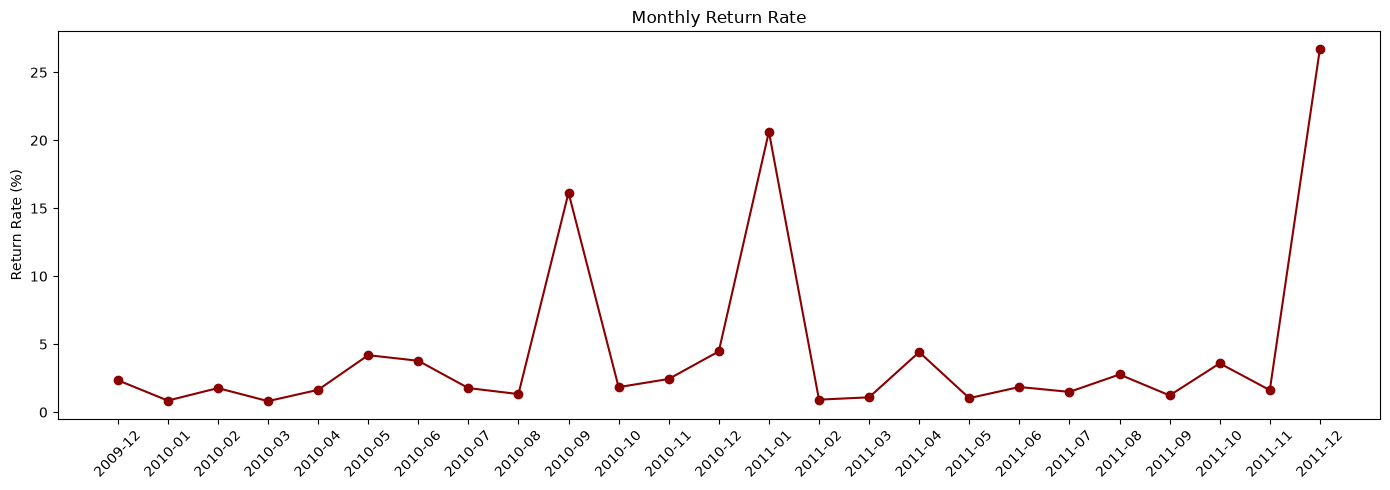

In [106]:
plt.figure(figsize=(14,5))
plt.plot(df_ret_rate["year_month"], df_ret_rate["return_rate"],c="darkred", marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Return Rate")
plt.ylabel("Return Rate (%)")
plt.tight_layout()
plt.show()

In [108]:
avg_return_rate = df_ret_rate["return_rate"].mean()
min_return_rate = df_ret_rate["return_rate"].min()
max_return_rate = df_ret_rate["return_rate"].max()
print(f"The monthly return lies in the range {min_return_rate:.2f}%-{max_return_rate:.2f}%, with average at {avg_return_rate:.2f}%.")

The monthly return lies in the range 0.81%-26.72%, with average 4.43%.


#### **Quarterly Return Rate**

In [102]:
q_ret_vol_quart = """
    SELECT s.year, s.quarter, s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT SUM(Quantity) AS sales_volume, strftime('%Y', InvoiceDate) as year,
        CASE
            WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
            WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
            WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
            WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
        END AS quarter
        FROM sales 
        WHERE year!='2009'
        GROUP BY year, quarter
    ) s
    LEFT JOIN (
        SELECT SUM(ABS(Quantity)) AS return_volume, strftime('%Y', InvoiceDate) as year,
        CASE
            WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
            WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
            WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
            WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
        END AS quarter
        FROM returns
        WHERE year!='2009'
        GROUP BY year, quarter
    ) r ON s.year = r.year AND s.quarter = r.quarter
    ORDER BY s.year, s.quarter
    """

df_ret_quart = pd.read_sql(q_ret_vol_quart,engine)
df_ret_quart["year_quarter"] = df_ret_quart["year"] + "-" + df_ret_quart["quarter"]

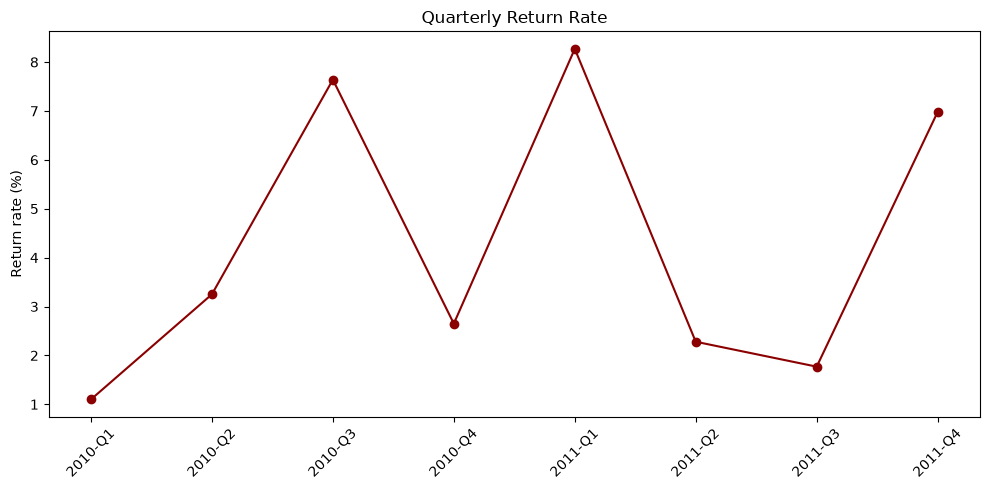

In [103]:
plt.figure(figsize=(10,5))
plt.plot(df_ret_quart["year_quarter"], df_ret_quart["return_rate"],c="darkred", marker='o')
plt.xticks(rotation=45)
plt.title("Quarterly Return Rate")
plt.ylabel("Return rate (%)")
plt.tight_layout()
plt.show()

Differently than revenue and volume of sales, the return rate does not appear to have a consistent behaviour throughout quarters. 

### 2.3.2 Return rate per Country

In [120]:
q_country_ret = """
    SELECT 
    s.Country,
    s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT Country, SUM(Quantity) AS sales_volume 
        FROM sales 
        GROUP BY Country
    ) s
    LEFT JOIN (
        SELECT Country, SUM(ABS(Quantity)) AS return_volume 
        FROM returns 
        GROUP BY Country
    ) r ON s.Country = r.Country
    ORDER BY return_rate DESC
    """

df_country_ret = pd.read_sql(q_country_ret, engine)


Text(0, 0.5, 'Return Rate (%)')

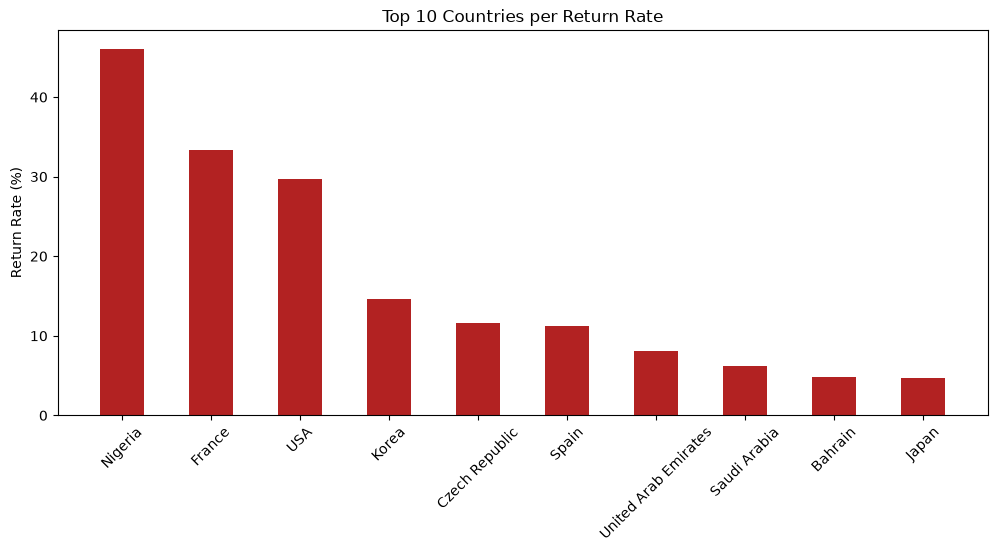

In [121]:
plt.figure(figsize=(12,5))
plt.bar(df_country_ret["Country"][:10], df_country_ret["return_rate"][:10], width=0.5, color="firebrick")
plt.xticks(rotation=45)
plt.title("Top 10 Countries per Return Rate")
plt.ylabel("Return Rate (%)")


In [126]:
df_country_ret.head(3)

,Country,sales_volume,return_volume,return_rate
0,Nigeria,102,47,46.08
1,France,270582,90274,33.36
2,USA,5259,1564,29.74


### 2.3.3 Return rate per Product

In [41]:
q_prod_ret = """
    SELECT 
    s.stock_code,
    s.Description,
    s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT UPPER(StockCode) as stock_code, Description, SUM(Quantity) AS sales_volume 
        FROM sales 
        GROUP BY stock_code
    ) s
    LEFT JOIN (
        SELECT UPPER(StockCode) as stock_code, Description, SUM(ABS(Quantity)) AS return_volume 
        FROM returns 
        GROUP BY stock_code
    ) r ON s.stock_code = r.stock_code
    ORDER BY return_rate DESC
    """

df_prod_ret = pd.read_sql(q_prod_ret, engine)


In [47]:
df_prod_ret[:][:10]

,stock_code,Description,sales_volume,return_volume,return_rate
0,35976B,WHITE SCANDINAVIAN HEART CHRISTMAS,1,12,1200.00
1,79301,FEATHER HEART LIGHTS,1,9,900.00
2,85043,RED HEART CANDY POP LIGHTS,1,3,300.00
3,37451,CERAMIC CAKE TEAPOT WITH CHERRY,1,2,200.00
4,85069,CREAM SWEETHEART DOUBLE SHELF,3,6,200.00
5,20879,TREE OF NOAH FESTIVE SCENTED CANDLE,57,96,168.42
6,85083,KISS REINDEER SCANDINAVIAN STOCKING,5,6,120.00
7,79323B,BLACK CHERRY LIGHTS,242,248,102.48
8,20715,LITTLE FLOWER SHOPPER BAG,400,400,100.00
9,20791,BLUE TILED SET OF 3 DRAWERS,5,5,100.00


>Note: Some products have a return rate higher than 100%. This is possibly due to items sold in previous years and returned in the years of interest. Since tracking returns from previous untracked sales does not inform on the return rate of the single product, for the product return analysis I will only focus on items that have a return rate under 100%.

Text(0, 0.5, 'Return Rate (%)')

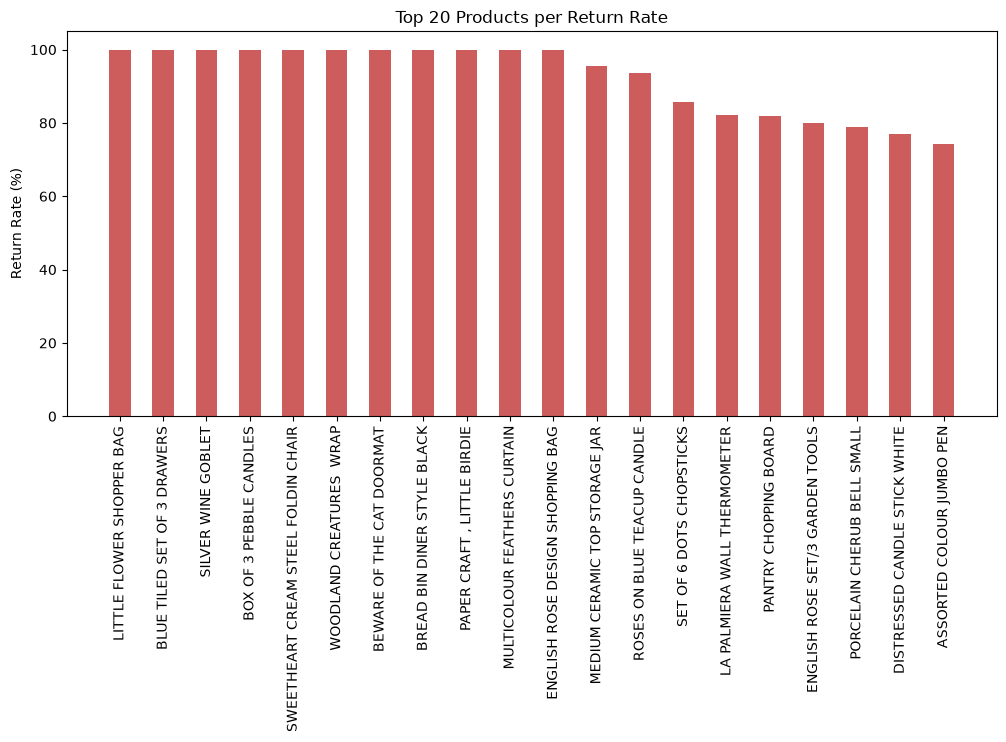

In [46]:
plt.figure(figsize=(12,5))
plt.bar(df_prod_ret[df_prod_ret["return_rate"]<=100]["Description"][:20], df_prod_ret[df_prod_ret["return_rate"]<=100]["return_rate"][:20], width=0.5, color="indianred")
plt.xticks(rotation=90)
plt.title("Top 20 Products per Return Rate")
plt.ylabel("Return Rate (%)")

## 2.4 Customer analysis

<div style="background:#00000; padding:12px; border-left:5px solid #3b82f6;">
<b>Note on Customer ID</b><br>
In the preliminary analysis, over 24000 entries with null Customer ID were detected. Since the missing customer ID is not significantly relevant to the revenue and volume analysis, it was decided to keep them, deleting only entries that were also missing other information (like Price).    
This has now to be taken into account: for the Customer analysis, <strong>all entries with null Customer ID will not be considered</strong>.
</div>

In [32]:
# To get info on how many rows are we removing from this analysis
sales_df = pd.read_sql("""SELECT * FROM sales""", engine)
print(f"{len(sales_df[sales_df["Customer ID"].isnull()])} rows will be excluded from the Customer analysis.")

226761 rows will be excluded from the Customer analysis.


In [33]:
q_customers = """
    SELECT COUNT(DISTINCT "Customer ID") as unique_customers
    FROM sales
    """
customers = pd.read_sql(q_customers, engine)
print(f"Total number of unique valid customers: {int(customers["unique_customers"][0])}")

Total number of unique valid customers: 5853


### 2.4.1 Customers per revenue

In [ ]:
q_cust_rev = """
    SELECT SUM(Quantity*Price) AS revenue, "Customer ID"
    FROM sales
    WHERE "Customer ID" IS NOT NULL
    GROUP BY "Customer ID"
    ORDER BY revenue DESC
    """
df_cust_rev = pd.read_sql(q_cust_rev, engine)
df_cust_rev["revenue_pct"] = df_cust_rev["revenue"]/df_cust_rev["revenue"].sum() *100

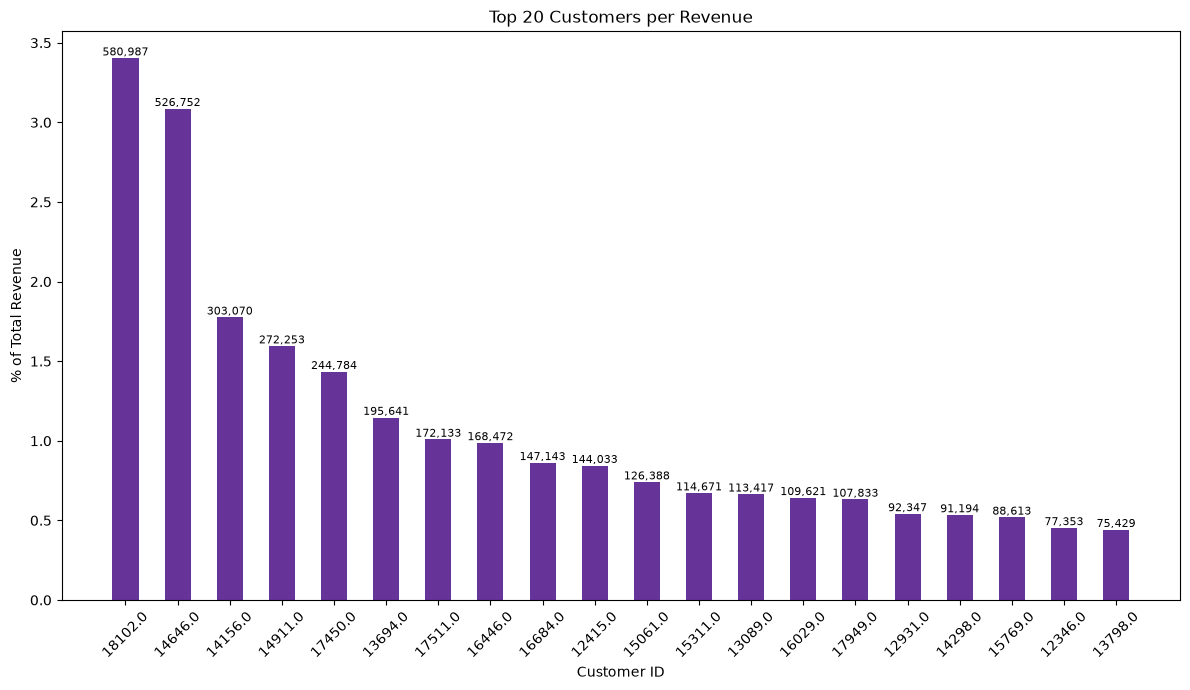

In [111]:
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(df_cust_rev["Customer ID"][:20], 
              df_cust_rev["revenue_pct"][:20], 
              width=0.5, color="rebeccapurple")

for bar, val in zip(bars, df_cust_rev["revenue"][:20]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Customer ID")
ax.set_ylabel("% of Total Revenue")
ax.set_title("Top 20 Customers per Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Pareto analysis**

In [37]:
df_cust_rev["cumulative_revenue"]=df_cust_rev["revenue"].cumsum()
df_cust_rev["cumulative_pct"]=df_cust_rev["cumulative_revenue"]/df_cust_rev["revenue"].sum()*100
df_cust_rev["customer_pct"]=range(1,len(df_cust_rev)+1)
df_cust_rev["customer_pct"]=df_cust_rev["customer_pct"]/len(df_cust_rev)*100

In [39]:
pareto = df_cust_rev[df_cust_rev["cumulative_pct"]>=80].iloc[0]
print(f"80% of revenue is generated by the top {pareto['customer_pct']:.1f}% of customers")

80% of revenue is generated by the top 23.1% of customers


### 2.4.2 Customers per Country

In [112]:
q_cust_country = """
    SELECT COUNT(*) AS customers, Country
    FROM sales
    WHERE "Customer ID" IS NOT NULL
    GROUP BY Country
    ORDER BY customers DESC
    """
df_cust_country = pd.read_sql(q_cust_country, engine)
df_cust_country["customers_pct"] = df_cust_country["customers"]/df_cust_country["customers"].sum() * 100

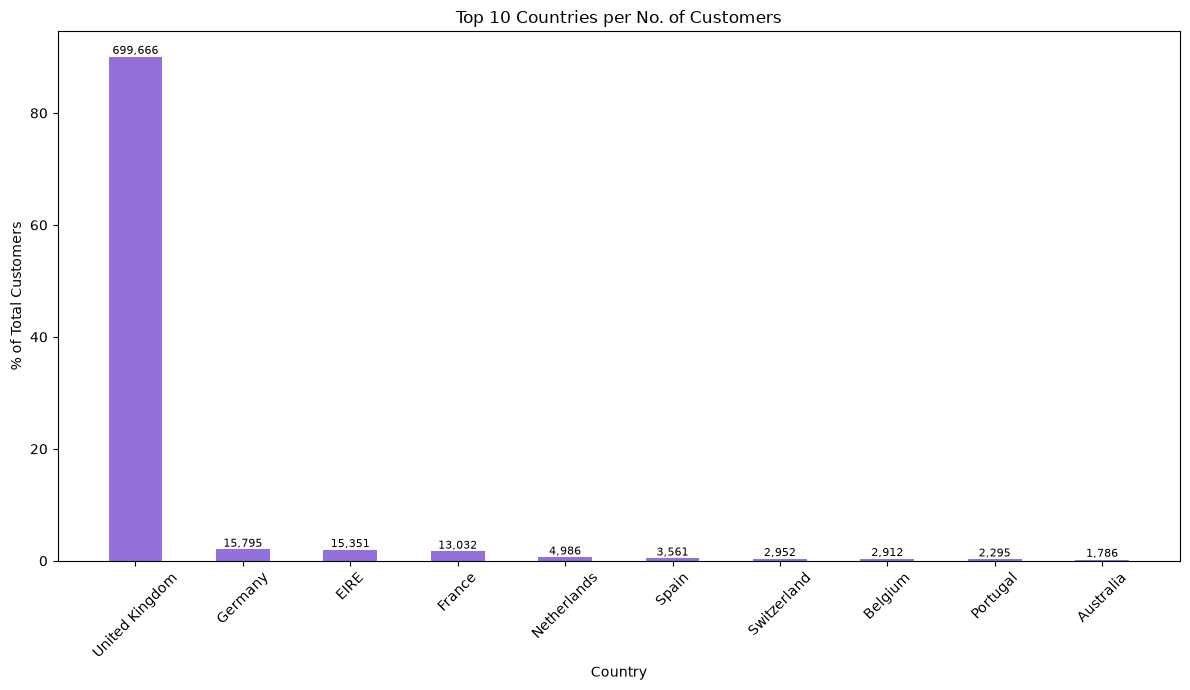

In [114]:
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(df_cust_country["Country"][:10], 
              df_cust_country["customers_pct"][:10], 
              width=0.5, color="mediumpurple")

for bar, val in zip(bars, df_cust_country["customers"][:10]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Country")
ax.set_ylabel("% of Total Customers")
ax.set_title("Top 10 Countries per No. of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [117]:
uk_cust = df_cust_country[df_cust_country["Country"]=="United Kingdom"]["customers_pct"].item()
print(f"{uk_cust:.2f}% of customers come from the United Kingdom.")

90.09% of customers come from the United Kingdom.


# **SUMMARY OF THE ANALYSIS**

The following bullet point list gathers the most relevant insights of the performed analysis:    
- The $80$% of the total revenue is accounted for by $23.1$% of total customers and $21.8$% of total products;    

- Of the total number of customers, $90.9$% come from the United Kingdom, which contributes to $82$% of the total number of sales and $85.4$% of the total revenue;    

- The volume of sales consistently increases in quarter 4 of each of the analyzed years, which contributes to $30.4$% and $30.6$% of the yearly volume of sales and to $35.3$% and $32.5$% of the yearly revenue for 2010 and 2011 respectively;    

- The return rate does not show a consistent trend over time. Its average is $4.43$% monthly, with the maximum return rate per month reaching $26.7$%;    

- Nigeria has the highest return rate, with $46.1$% of returns overall, followed by France with $33.4$% and the USA with $29.7$%.